# Phase 2 — GAF Encoding for NASA SOH Data

**Project:** Battery SOH Estimation using GAF + C-W-DCGAN-GP + CNN-BiLSTM-Attention
**Input (from Phase 1):** `nasa_soh_labels.csv`, `nasa_raw_signals.pkl`

**Goal of this notebook (Phase 2 only):**
1. Downsample each discharge cycle's Voltage/Current/Temperature signal to a fixed length (128 points).
2. Min-Max scale each signal to [0,1] and apply the GASF transform (per Opy Das's methodology).
3. Stack the three GASF images (V, I, T) into one 3-channel RGB GAF image per cycle.
4. **Validate inverse-GAF reconstruction** — this is mandatory before any GAN training. If this step
   fails, nothing downstream (GAN, classifier) can be trusted.
5. Apply light multiplicative noise augmentation to expand the image set.
6. Save the final image dataset + SOH labels, ready for Phase 3 (GAN training).

This notebook does **not** train any GAN or classifier — that starts in Phase 3.


## 1. Setup & Load Phase 1 Outputs

In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)
plt.rcParams["figure.figsize"] = (10, 5)

# If continuing in the SAME Kaggle session as Phase 1, these files are already in /kaggle/working.
# If running as a NEW notebook, add Phase 1's output as a Kaggle Dataset first (Output -> "Create Dataset"
# from the Phase 1 notebook, or attach the two files manually), then point INPUT_DIR to that dataset path.

INPUT_DIR = INPUT_DIR = "/kaggle/input/datasets/tasniaturin12/nasa-soh-phase1-output"  # change to "/kaggle/input/<your-phase1-dataset>" if loading from a separate dataset
OUTPUT_DIR = "/kaggle/working"

soh_df = pd.read_csv(os.path.join(INPUT_DIR, "nasa_soh_labels.csv"))

with open(os.path.join(INPUT_DIR, "nasa_raw_signals.pkl"), "rb") as f:
    all_raw_signals = pickle.load(f)

print(soh_df.shape)
soh_df.head()


(636, 7)


,battery_id,cycle_index,capacity_Ah,ambient_temperature,filename,SOH_percent,below_eol
0,B0005,0,1.856487,24,05122.csv,92.824371,False
1,B0005,1,1.846327,24,05124.csv,92.316362,False
2,B0005,2,1.835349,24,05126.csv,91.767460,False
3,B0005,3,1.835263,24,05128.csv,91.763126,False
4,B0005,4,1.834646,24,05130.csv,91.732275,False


In [2]:
import os
print(os.listdir("/kaggle/input"))

['datasets']


In [3]:
import os
for dirpath, dirnames, filenames in os.walk("/kaggle/input/datasets"):
    print(dirpath)
    for f in filenames[:10]:
        print("   ", f)

/kaggle/input/datasets
/kaggle/input/datasets/patrickfleith
/kaggle/input/datasets/patrickfleith/nasa-battery-dataset
/kaggle/input/datasets/patrickfleith/nasa-battery-dataset/cleaned_dataset
    metadata.csv
/kaggle/input/datasets/patrickfleith/nasa-battery-dataset/cleaned_dataset/extra_infos
    README_49_50_51_52.txt
    README_45_46_47_48.txt
    README_05_06_07_18.txt
    README_29_30_31_32.txt
    README_25_26_27_28.txt
    README_33_34_36.txt
    README_53_54_55_56.txt
    README_41_42_43_44.txt
    README_38_39_40.txt
/kaggle/input/datasets/patrickfleith/nasa-battery-dataset/cleaned_dataset/data
    02421.csv
    04530.csv
    06086.csv
    01486.csv
    05955.csv
    04119.csv
    06847.csv
    06029.csv
    04825.csv
    06578.csv
/kaggle/input/datasets/tasniaturin12
/kaggle/input/datasets/tasniaturin12/nasa-soh-phase1-output
    nasa_raw_signals.pkl
    nasa_soh_labels.csv


## 2. Downsampling to a Fixed Length

Each discharge cycle has a different raw signal length (e.g. 197, 335, ...). To build GAF images we
need a **fixed length** for every cycle — 128 points, matching the standard 128×128 GASF matrix size
used in CNN-based generator/discriminator architectures (same choice as Opy's MIT-dataset work).

We use linear interpolation over the cycle's time axis so the 128 sampled points still represent the
same relative phases of the discharge curve (initial plateau, voltage drop, knee region, cutoff).


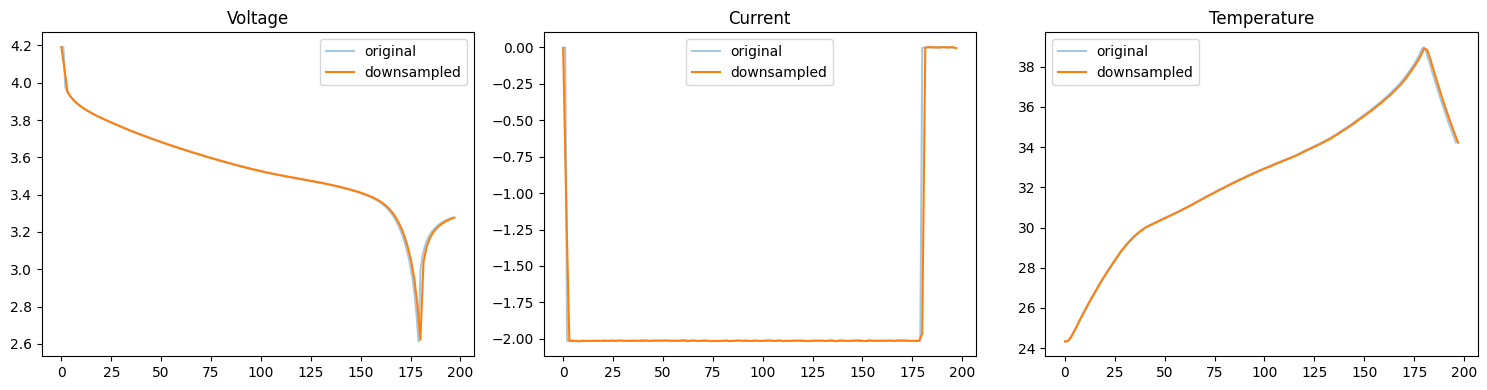

In [4]:
TARGET_LEN = 128

def downsample_signal(values, target_len=TARGET_LEN):
    """Linearly interpolate a 1D signal to a fixed number of points."""
    values = np.asarray(values, dtype=float)
    if len(values) == target_len:
        return values
    original_idx = np.linspace(0, 1, len(values))
    target_idx = np.linspace(0, 1, target_len)
    return np.interp(target_idx, original_idx, values)


def downsample_cycle(sig, target_len=TARGET_LEN):
    return {
        "voltage": downsample_signal(sig["voltage"], target_len),
        "current": downsample_signal(sig["current"], target_len),
        "temperature": downsample_signal(sig["temperature"], target_len),
    }


# Quick check on one example cycle
example_battery = list(all_raw_signals.keys())[0]
example_cycle = 0
sig = all_raw_signals[example_battery][example_cycle]
ds = downsample_cycle(sig)

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].plot(sig["voltage"], alpha=0.4, label="original"); ax[0].plot(np.linspace(0, len(sig["voltage"]), TARGET_LEN), ds["voltage"], label="downsampled"); ax[0].set_title("Voltage"); ax[0].legend()
ax[1].plot(sig["current"], alpha=0.4, label="original"); ax[1].plot(np.linspace(0, len(sig["current"]), TARGET_LEN), ds["current"], label="downsampled"); ax[1].set_title("Current"); ax[1].legend()
ax[2].plot(sig["temperature"], alpha=0.4, label="original"); ax[2].plot(np.linspace(0, len(sig["temperature"]), TARGET_LEN), ds["temperature"], label="downsampled"); ax[2].set_title("Temperature"); ax[2].legend()
plt.tight_layout()
plt.show()


## 3. GAF (GASF) Transform — Forward and Inverse

Following the same formulation as Opy's thesis:

1. **Min-Max scale** the signal to [0,1]:  `x' = (x - min) / (max - min)`
2. **Polar mapping**:  `φ = arccos(x')`, so `φ ∈ [0, π/2]`
3. **GASF matrix**:  `GASF[i,j] = cos(φ_i + φ_j)`
4. **Inverse** (from the diagonal only):  `φ_i = 0.5 · arccos(GASF[i,i])`, then `x'_i = cos(φ_i)`,
   then rescale back using the original min/max.

We keep the original min/max of every signal so reconstruction is exact (not approximate).


In [5]:
def gasf_transform(signal):
    """
    signal: 1D array, length N
    Returns: (gasf_matrix [N,N], min_val, max_val)
    """
    min_val, max_val = float(np.min(signal)), float(np.max(signal))
    if max_val - min_val < 1e-12:
        # Constant signal edge case -- avoid divide by zero
        scaled = np.zeros_like(signal)
    else:
        scaled = (signal - min_val) / (max_val - min_val)
    scaled = np.clip(scaled, 0.0, 1.0)
    phi = np.arccos(scaled)
    gasf = np.cos(phi[:, None] + phi[None, :])
    return gasf, min_val, max_val


def inverse_gasf(gasf_matrix, min_val, max_val):
    """Reconstruct the original 1D signal from a GASF matrix's diagonal."""
    diag = np.clip(np.diag(gasf_matrix), -1.0, 1.0)
    phi = 0.5 * np.arccos(diag)
    scaled = np.cos(phi)
    return scaled * (max_val - min_val) + min_val


## 4. Validate Reconstruction on One Example Cycle (mandatory check)

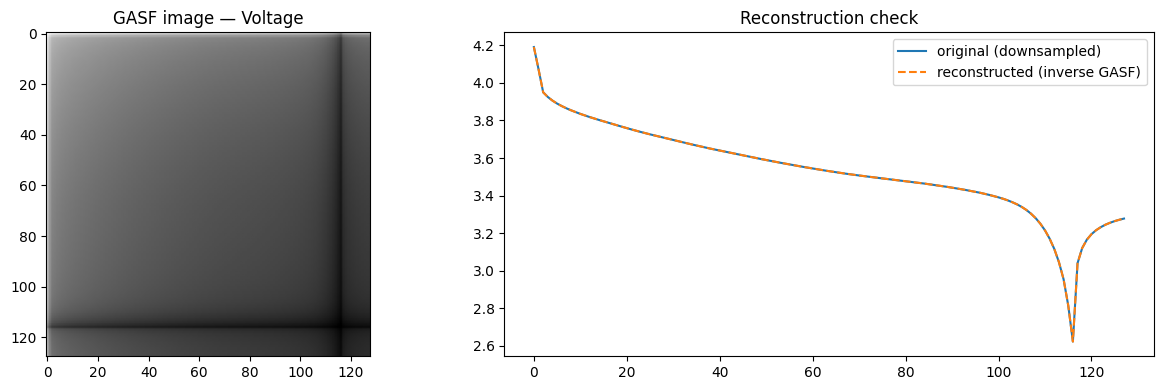

Reconstruction MAE (Voltage): 0.000000
If this is not close to 0 (e.g. < 1e-3), STOP and debug before proceeding -- GAN training on broken encodings will silently waste hours of compute.


In [6]:
gasf_v, min_v, max_v = gasf_transform(ds["voltage"])
recon_v = inverse_gasf(gasf_v, min_v, max_v)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].imshow(gasf_v, cmap="gray")
axes[0].set_title("GASF image — Voltage")

axes[1].plot(ds["voltage"], label="original (downsampled)")
axes[1].plot(recon_v, "--", label="reconstructed (inverse GASF)")
axes[1].set_title("Reconstruction check")
axes[1].legend()
plt.tight_layout()
plt.show()

mae = np.mean(np.abs(ds["voltage"] - recon_v))
print(f"Reconstruction MAE (Voltage): {mae:.6f}")
print("If this is not close to 0 (e.g. < 1e-3), STOP and debug before proceeding -- "
      "GAN training on broken encodings will silently waste hours of compute.")


## 5. Build Multi-Channel GAF Images for All Cycles

Each cycle becomes one 128×128×3 image: Voltage → Red, Current → Green, Temperature → Blue.
We also keep the per-channel min/max for every cycle so any generated/synthetic image can later
be inverse-transformed back into real-unit signals.


In [7]:
def build_gaf_image(sig_downsampled):
    """
    sig_downsampled: dict with 'voltage', 'current', 'temperature' arrays (length TARGET_LEN)
    Returns: (image [128,128,3] in [-1,1], minmax dict for inverse transform)
    """
    gasf_v, min_v, max_v = gasf_transform(sig_downsampled["voltage"])
    gasf_i, min_i, max_i = gasf_transform(sig_downsampled["current"])
    gasf_t, min_t, max_t = gasf_transform(sig_downsampled["temperature"])

    image = np.stack([gasf_v, gasf_i, gasf_t], axis=-1)  # [128,128,3], values in [-1,1]
    minmax = {
        "voltage": (min_v, max_v),
        "current": (min_i, max_i),
        "temperature": (min_t, max_t),
    }
    return image.astype(np.float32), minmax


gaf_images = {}      # {battery_id: {cycle_index: image}}
gaf_minmax = {}       # {battery_id: {cycle_index: minmax dict}}

for battery_id, cycles in all_raw_signals.items():
    gaf_images[battery_id] = {}
    gaf_minmax[battery_id] = {}
    for cycle_index, sig in cycles.items():
        ds_sig = downsample_cycle(sig)
        image, minmax = build_gaf_image(ds_sig)
        gaf_images[battery_id][cycle_index] = image
        gaf_minmax[battery_id][cycle_index] = minmax
    print(f"{battery_id}: {len(gaf_images[battery_id])} GAF images built")


B0005: 168 GAF images built
B0006: 168 GAF images built
B0007: 168 GAF images built
B0018: 132 GAF images built


## 6. Visualise a Few GAF Images Across the Degradation Timeline

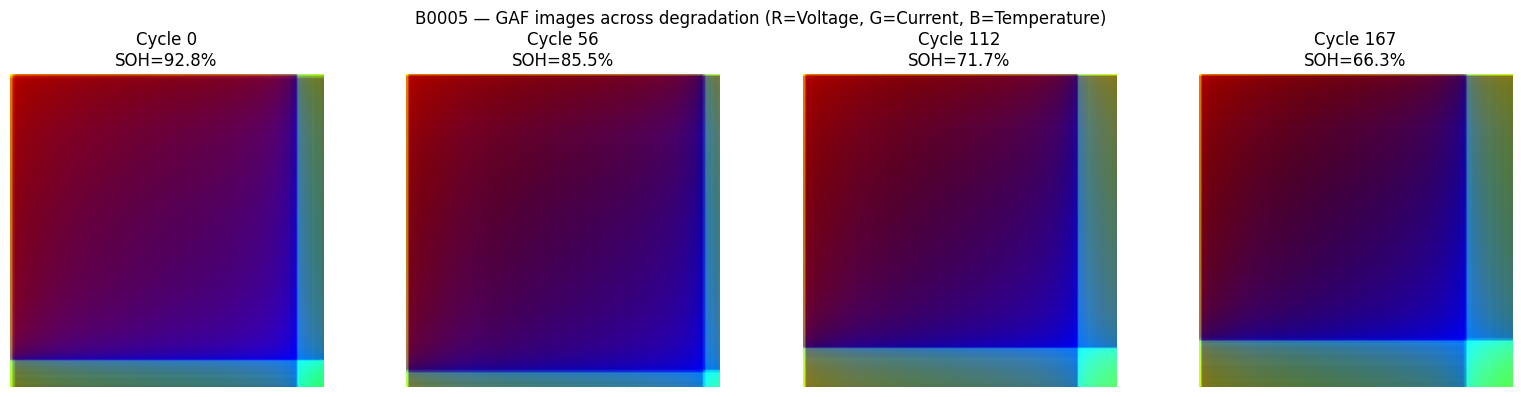

In [8]:
example_battery = list(gaf_images.keys())[0]
cycle_ids = sorted(gaf_images[example_battery].keys())
sample_cycles = [cycle_ids[0], cycle_ids[len(cycle_ids)//3], cycle_ids[2*len(cycle_ids)//3], cycle_ids[-1]]

fig, axes = plt.subplots(1, len(sample_cycles), figsize=(16, 4))
for ax, c in zip(axes, sample_cycles):
    img = gaf_images[example_battery][c]
    # Rescale [-1,1] -> [0,1] for display
    display_img = (img + 1) / 2
    ax.imshow(display_img)
    soh_val = soh_df[(soh_df.battery_id == example_battery) & (soh_df.cycle_index == c)]["SOH_percent"].values[0]
    ax.set_title(f"Cycle {c}\nSOH={soh_val:.1f}%")
    ax.axis("off")

fig.suptitle(f"{example_battery} — GAF images across degradation (R=Voltage, G=Current, B=Temperature)")
plt.tight_layout()
plt.show()


## 7. Image Augmentation (4% Multiplicative Noise)

Same approach as Opy's thesis: add small multiplicative noise to the GAF images to increase sample
diversity and reduce GAN overfitting on a small cycle count. This is applied **after** the clean
images are saved, so the clean originals remain available for fair resemblance evaluation later.


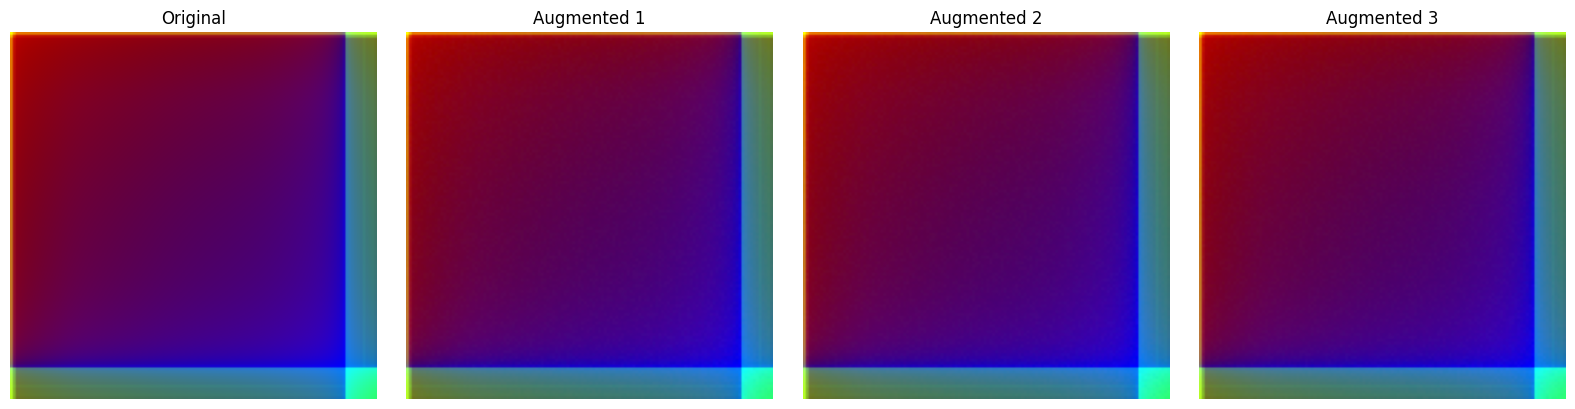

In [9]:
NOISE_LEVEL = 0.04
N_AUGMENTED_PER_IMAGE = 3   # how many noisy variants to create per real image

def augment_image(image, noise_level=NOISE_LEVEL):
    noise = 1.0 + np.random.uniform(-noise_level, noise_level, size=image.shape)
    augmented = image * noise
    return np.clip(augmented, -1.0, 1.0).astype(np.float32)


# Example: augment a handful of images from one battery to check it looks reasonable
fig, axes = plt.subplots(1, N_AUGMENTED_PER_IMAGE + 1, figsize=(16, 4))
base_img = gaf_images[example_battery][cycle_ids[0]]
axes[0].imshow((base_img + 1) / 2); axes[0].set_title("Original"); axes[0].axis("off")
for i in range(N_AUGMENTED_PER_IMAGE):
    aug = augment_image(base_img)
    axes[i+1].imshow((aug + 1) / 2); axes[i+1].set_title(f"Augmented {i+1}"); axes[i+1].axis("off")
plt.tight_layout()
plt.show()


## 8. Assemble the Final Dataset for GAN Training

Build a single array of images + matching SOH labels (clean + augmented), along with per-image
min/max metadata for inverse transformation later. We keep a `is_augmented` flag and `source_cycle`
reference so augmented samples can always be traced back to their real source cycle — this matters
for Phase 5 when splitting train/test to avoid leakage.


In [10]:
records = []   # one row per image (real or augmented)
images_list = []

for battery_id, cycles in gaf_images.items():
    for cycle_index, image in cycles.items():
        soh_row = soh_df[(soh_df.battery_id == battery_id) & (soh_df.cycle_index == cycle_index)]
        soh_val = float(soh_row["SOH_percent"].values[0])

        # Real (clean) image
        images_list.append(image)
        records.append({
            "battery_id": battery_id,
            "source_cycle": cycle_index,
            "SOH_percent": soh_val,
            "is_augmented": False,
        })

        # Augmented variants
        for a in range(N_AUGMENTED_PER_IMAGE):
            images_list.append(augment_image(image))
            records.append({
                "battery_id": battery_id,
                "source_cycle": cycle_index,
                "SOH_percent": soh_val,
                "is_augmented": True,
            })

images_array = np.stack(images_list, axis=0)   # [N, 128, 128, 3]
labels_df = pd.DataFrame(records)

print("Final image array shape:", images_array.shape)
print(labels_df["is_augmented"].value_counts())
labels_df.head()


Final image array shape: (2544, 128, 128, 3)
is_augmented
True     1908
False     636
Name: count, dtype: int64


,battery_id,source_cycle,SOH_percent,is_augmented
0,B0005,0,92.824371,False
1,B0005,0,92.824371,True
2,B0005,0,92.824371,True
3,B0005,0,92.824371,True
4,B0005,1,92.316362,False


## 9. Save Outputs for Phase 3 (GAN Training)

In [11]:
# Images: saved as compressed .npz (single array, indexed the same order as labels_df rows)
images_path = os.path.join(OUTPUT_DIR, "nasa_gaf_images.npz")
np.savez_compressed(images_path, images=images_array)
print("Saved:", images_path)

# Labels + metadata
labels_path = os.path.join(OUTPUT_DIR, "nasa_gaf_labels.csv")
labels_df.to_csv(labels_path, index=False)
print("Saved:", labels_path)

# Per-cycle min/max (needed for inverse-GAF later, e.g. when validating GAN-generated images)
minmax_path = os.path.join(OUTPUT_DIR, "nasa_gaf_minmax.pkl")
with open(minmax_path, "wb") as f:
    pickle.dump(gaf_minmax, f)
print("Saved:", minmax_path)

print("\nPhase 2 complete.")
print(f"Total images (real + augmented): {len(labels_df)}")
print(f"Real images only: {(~labels_df['is_augmented']).sum()}")


Saved: /kaggle/working/nasa_gaf_images.npz
Saved: /kaggle/working/nasa_gaf_labels.csv
Saved: /kaggle/working/nasa_gaf_minmax.pkl

Phase 2 complete.
Total images (real + augmented): 2544
Real images only: 636


---
### Next: Phase 3 (separate notebook)

- Train DCGAN → WGAN → WGAN-GP → Conditional W-DCGAN-GP (C-W-DCGAN-GP) progressively on
  `nasa_gaf_images.npz`, conditioned on SOH bin / degradation stage.
- Track generator/critic loss curves at each stage.
- Generate synthetic GAF images at checkpoints for later resemblance evaluation (Phase 4).
